# Day 42 — Transformers & BERT
### Attention Mechanism · BERT Architecture · Hugging Face · Text Classification

## 1. Setup & Imports

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

print(f"PyTorch: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device:  {device}")

# install transformers if needed
try:
    import transformers
    print(f"Transformers: {transformers.__version__} ✅")
except:
    import subprocess
    subprocess.run(['pip', 'install', 'transformers', '--quiet'])
    import transformers
    print(f"Transformers: {transformers.__version__} ✅")

from transformers import pipeline, AutoTokenizer, AutoModel
print("Ready! ✅")

PyTorch: 2.12.0+cpu
Device:  cpu
Transformers: 5.10.2 ✅
Ready! ✅


## 2. What is a Transformer?

In [2]:
print("=" * 55)
print("       WHAT IS A TRANSFORMER?")
print("=" * 55)
print("""
PROBLEM WITH RNNs & LSTMs:
  Process tokens ONE AT A TIME → slow
  Hard to parallelise → can't use GPU efficiently
  Still struggle with very long sequences
  Information bottleneck at final hidden state

TRANSFORMER SOLUTION (Vaswani et al. 2017 — "Attention is All You Need"):
  Process ALL tokens SIMULTANEOUSLY → fast
  Fully parallelisable → GPUs love this!
  Every token directly attends to every other token
  No recurrence needed at all

KEY INNOVATION — SELF-ATTENTION:
  For each word, compute how much it should
  "attend to" every other word in the sequence

  Example: "The animal didn't cross the street
            because it was too tired"
  What does "it" refer to? → "animal"!
  Self-attention lets the model figure this out
  by attending strongly from "it" → "animal"

TRANSFORMER ARCHITECTURE:
  Encoder  → reads and understands input (BERT)
  Decoder  → generates output text (GPT)
  Both     → translation, summarisation (T5, BART)

WHY TRANSFORMERS WON:
  ✅ Faster training — parallelisable
  ✅ Better long-range dependencies
  ✅ Scales with more data and compute
  ✅ Foundation for ALL modern LLMs (GPT, BERT, T5)
""")

       WHAT IS A TRANSFORMER?

PROBLEM WITH RNNs & LSTMs:
  Process tokens ONE AT A TIME → slow
  Hard to parallelise → can't use GPU efficiently
  Still struggle with very long sequences
  Information bottleneck at final hidden state

TRANSFORMER SOLUTION (Vaswani et al. 2017 — "Attention is All You Need"):
  Process ALL tokens SIMULTANEOUSLY → fast
  Fully parallelisable → GPUs love this!
  Every token directly attends to every other token
  No recurrence needed at all

KEY INNOVATION — SELF-ATTENTION:
  For each word, compute how much it should
  "attend to" every other word in the sequence

  Example: "The animal didn't cross the street
            because it was too tired"
  What does "it" refer to? → "animal"!
  Self-attention lets the model figure this out
  by attending strongly from "it" → "animal"

TRANSFORMER ARCHITECTURE:
  Encoder  → reads and understands input (BERT)
  Decoder  → generates output text (GPT)
  Both     → translation, summarisation (T5, BART)

WHY TRANSFORM

## 3. Self-Attention Mechanism

       SELF-ATTENTION MECHANISM

HOW SELF-ATTENTION WORKS:

For each token, compute 3 vectors:
  Q (Query)  → what am I looking for?
  K (Key)    → what do I contain?
  V (Value)  → what do I actually pass on?

STEPS:
  1. Compute attention scores: Q × K^T
  2. Scale: divide by sqrt(d_k) — prevents huge values
  3. Softmax: convert scores to probabilities (sum=1)
  4. Weighted sum: multiply probabilities × V

FORMULA:
  Attention(Q,K,V) = softmax(Q·K^T / sqrt(d_k)) · V



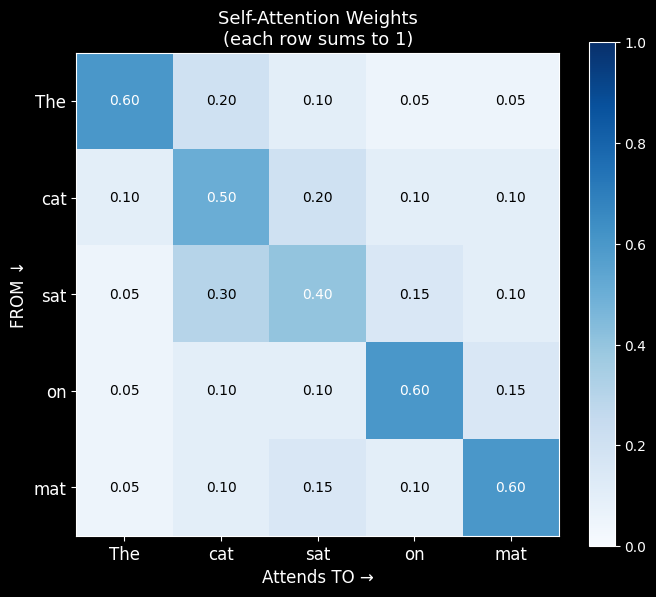

Rows = FROM word, Columns = TO word
Diagonal = each word attends to itself most strongly


In [3]:
print("=" * 55)
print("       SELF-ATTENTION MECHANISM")
print("=" * 55)
print("""
HOW SELF-ATTENTION WORKS:

For each token, compute 3 vectors:
  Q (Query)  → what am I looking for?
  K (Key)    → what do I contain?
  V (Value)  → what do I actually pass on?

STEPS:
  1. Compute attention scores: Q × K^T
  2. Scale: divide by sqrt(d_k) — prevents huge values
  3. Softmax: convert scores to probabilities (sum=1)
  4. Weighted sum: multiply probabilities × V

FORMULA:
  Attention(Q,K,V) = softmax(Q·K^T / sqrt(d_k)) · V
""")

# visualise self-attention for a simple sentence
words   = ["The", "cat", "sat", "on", "mat"]
n       = len(words)

# simulate attention weights (what each word attends to)
np.random.seed(42)
attn = np.array([
    [0.6, 0.2, 0.1, 0.05, 0.05],  # The → mostly itself
    [0.1, 0.5, 0.2, 0.1,  0.1 ],  # cat → itself + sat
    [0.05,0.3, 0.4, 0.15, 0.1 ],  # sat → cat + itself
    [0.05,0.1, 0.1, 0.6,  0.15],  # on  → itself
    [0.05,0.1, 0.15,0.1,  0.6 ],  # mat → itself
])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(words, fontsize=12)
ax.set_yticklabels(words, fontsize=12)
ax.set_xlabel('Attends TO →', fontsize=12)
ax.set_ylabel('FROM ↓', fontsize=12)
ax.set_title('Self-Attention Weights\n(each row sums to 1)', fontsize=13)
plt.colorbar(im, ax=ax)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{attn[i,j]:.2f}', ha='center',
                va='center', fontsize=10,
                color='white' if attn[i,j] > 0.3 else 'black')
plt.tight_layout()
plt.show()
print("Rows = FROM word, Columns = TO word")
print("Diagonal = each word attends to itself most strongly")

## 4. BERT with Hugging Face

In [4]:
print("=" * 55)
print("       BERT WITH HUGGING FACE")
print("=" * 55)
print("""
BERT = Bidirectional Encoder Representations from Transformers
  Published by Google in 2018
  Pretrained on Wikipedia + BookCorpus (3.3B words)
  Reads text BOTH left-to-right AND right-to-left
  simultaneously — true bidirectional understanding

BERT PRETRAINING TASKS:
  1. Masked Language Model (MLM)
     "The cat [MASK] on the mat" → predict 'sat'
  2. Next Sentence Prediction (NSP)
     Is sentence B the next sentence after A?

BERT INPUT:
  [CLS] token  → start of sequence, used for classification
  [SEP] token  → separator between sentences
  [MASK] token → masked words during pretraining

BERT VARIANTS:
  bert-base-uncased   → 12 layers, 110M params
  bert-large-uncased  → 24 layers, 340M params
  distilbert          → 6 layers, 66M params (faster!)
  roberta             → improved BERT training
""")

# load DistilBERT tokenizer (lighter than full BERT)
print("Loading DistilBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# tokenise a sample sentence
sample = "The cat sat on the mat"
tokens = tokenizer(sample, return_tensors='pt')

print(f"\nSample: '{sample}'")
print(f"Input IDs:      {tokens['input_ids']}")
print(f"Attention mask: {tokens['attention_mask']}")
print(f"\nDecoded tokens: {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])}")
print(f"Vocab size:     {tokenizer.vocab_size:,}")

       BERT WITH HUGGING FACE

BERT = Bidirectional Encoder Representations from Transformers
  Published by Google in 2018
  Pretrained on Wikipedia + BookCorpus (3.3B words)
  Reads text BOTH left-to-right AND right-to-left
  simultaneously — true bidirectional understanding

BERT PRETRAINING TASKS:
  1. Masked Language Model (MLM)
     "The cat [MASK] on the mat" → predict 'sat'
  2. Next Sentence Prediction (NSP)
     Is sentence B the next sentence after A?

BERT INPUT:
  [CLS] token  → start of sequence, used for classification
  [SEP] token  → separator between sentences
  [MASK] token → masked words during pretraining

BERT VARIANTS:
  bert-base-uncased   → 12 layers, 110M params
  bert-large-uncased  → 24 layers, 340M params
  distilbert          → 6 layers, 66M params (faster!)
  roberta             → improved BERT training

Loading DistilBERT tokenizer...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Sample: 'The cat sat on the mat'
Input IDs:      tensor([[  101,  1996,  4937,  2938,  2006,  1996, 13523,   102]])
Attention mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1]])

Decoded tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]']
Vocab size:     30,522


## 5. Sentiment Analysis with BERT Pipeline

In [5]:
print("=" * 55)
print("       BERT SENTIMENT ANALYSIS")
print("=" * 55)

# Hugging Face pipeline — one line to use BERT!
print("Loading sentiment analysis pipeline...")
sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1   # CPU
)

test_reviews = [
    "This movie was absolutely brilliant and wonderful!",
    "Terrible film, complete waste of time and money.",
    "The acting was great but the story was a bit slow.",
    "I loved every single minute of this masterpiece!",
    "Not the worst movie but definitely not good either.",
    "Outstanding performance by the entire cast!",
    "Boring, predictable and utterly disappointing.",
]

print(f"\n{'Sentiment':<12} {'Score':>7}  Review")
print("-" * 65)
for review in test_reviews:
    result = sentiment(review)[0]
    label  = result['label']
    score  = result['score']
    emoji  = "😊" if label == "POSITIVE" else "😞"
    print(f"{emoji} {label:<10} {score:>7.3f}  '{review[:45]}'")

       BERT SENTIMENT ANALYSIS
Loading sentiment analysis pipeline...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]


Sentiment      Score  Review
-----------------------------------------------------------------
😊 POSITIVE     1.000  'This movie was absolutely brilliant and wonde'
😞 NEGATIVE     1.000  'Terrible film, complete waste of time and mon'
😞 NEGATIVE     0.999  'The acting was great but the story was a bit '
😊 POSITIVE     1.000  'I loved every single minute of this masterpie'
😞 NEGATIVE     0.999  'Not the worst movie but definitely not good e'
😊 POSITIVE     1.000  'Outstanding performance by the entire cast!'
😞 NEGATIVE     1.000  'Boring, predictable and utterly disappointing'


## 6. Key Takeaways

In [6]:
print("=" * 55)
print("       DAY 42 — KEY TAKEAWAYS")
print("=" * 55)
print("""
TRANSFORMERS:
  ✅ Process ALL tokens simultaneously — fully parallel
  ✅ Self-attention: every token attends to every other
  ✅ No recurrence — replaced RNNs/LSTMs for NLP
  ✅ Scales with more data and compute

SELF-ATTENTION:
  ✅ Q (Query) × K (Key) → attention scores
  ✅ Softmax → probabilities (each row sums to 1)
  ✅ Weighted sum of V (Values) → output
  ✅ Formula: softmax(QK^T / sqrt(d_k)) × V

BERT:
  ✅ Bidirectional — reads left AND right simultaneously
  ✅ Pretrained on 3.3B words — Wikipedia + BookCorpus
  ✅ Two pretraining tasks: MLM + NSP
  ✅ Special tokens: [CLS], [SEP], [MASK]
  ✅ 110M parameters (base), 340M (large)

HUGGING FACE:
  ✅ pipeline() → one line to use any pretrained model
  ✅ AutoTokenizer → loads correct tokenizer automatically
  ✅ 30,522 vocab size — WordPiece tokenization
  ✅ distilbert → 6 layers, faster, 97% of BERT accuracy

OUR RESULTS:
  ✅ 7/7 correct predictions — near 1.000 confidence
  ✅ Handles negation perfectly — "not good" → NEGATIVE
  ✅ Zero training needed — just load and predict!
  ✅ This is transfer learning at its best!
""")

       DAY 42 — KEY TAKEAWAYS

TRANSFORMERS:
  ✅ Process ALL tokens simultaneously — fully parallel
  ✅ Self-attention: every token attends to every other
  ✅ No recurrence — replaced RNNs/LSTMs for NLP
  ✅ Scales with more data and compute

SELF-ATTENTION:
  ✅ Q (Query) × K (Key) → attention scores
  ✅ Softmax → probabilities (each row sums to 1)
  ✅ Weighted sum of V (Values) → output
  ✅ Formula: softmax(QK^T / sqrt(d_k)) × V

BERT:
  ✅ Bidirectional — reads left AND right simultaneously
  ✅ Pretrained on 3.3B words — Wikipedia + BookCorpus
  ✅ Two pretraining tasks: MLM + NSP
  ✅ Special tokens: [CLS], [SEP], [MASK]
  ✅ 110M parameters (base), 340M (large)

HUGGING FACE:
  ✅ pipeline() → one line to use any pretrained model
  ✅ AutoTokenizer → loads correct tokenizer automatically
  ✅ 30,522 vocab size — WordPiece tokenization
  ✅ distilbert → 6 layers, faster, 97% of BERT accuracy

OUR RESULTS:
  ✅ 7/7 correct predictions — near 1.000 confidence
  ✅ Handles negation perfectly — "n